# CD-ADAPT-VQE en grafos aleatorios $n=6$

Analiza los resultados de **CD-ADAPT-VQE** sobre un ensemble de 300 grafos aleatorios de $n=6$, comparando el pool de operadores $\ell=1$ contra $\ell=2$, con y sin un presupuesto común de iteraciones.

Los datos base se generaron corriendo `cluster/main.py` (grafos en `datos/grafos_n6.txt`, $M=300$) para $\ell=1$ y $\ell=2$, y quedaron en `resultados/csv/resultados_resumen_n6_l{1,2}_1_300.csv` y sus JSON completos análogos.

La sección de "presupuesto común" trunca esas trazas completas al mínimo número de iteraciones entre $\ell=1$ y $\ell=2$ por grafo, para comparar ambos pools bajo el mismo número de operadores agregados al ansatz.

## 0. Set-up

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

mpl.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.color"       : "#DDDDDD",
    "grid.linewidth"   : 0.6,
    "grid.alpha"       : 1.0,
    "font.family"      : "serif",
    "font.size"        : 11,
    "axes.labelsize"   : 11,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "legend.fontsize"  : 10,
    "legend.framealpha": 0.9,
    "legend.edgecolor" : "#BBBBBB",
    "xtick.labelsize"  : 10,
    "ytick.labelsize"  : 10,
    "lines.linewidth"  : 2.0,
    "patch.linewidth"  : 0.4,
    "savefig.dpi"      : 150,
    "savefig.bbox"     : "tight",
    "savefig.facecolor": "white",
})

# Colorblind-safe palette (Wong 2011)
C1 = "#0072B2"   # blue      – l = 1
C2 = "#D55E00"   # vermilion – l = 2

import sys
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from funciones.utilidades import (
    compute_error_stats,
    get_num_ops,
    truncate_trace_like_normal,
    truncate_ansatz_list,
    truncate_result_to_budget,
    save_json,
    save_csv,
)

## Análisis: convergencia libre

### 0. Carga de datos

In [84]:
# Cargar ambos archivos
df1 = pd.read_csv("../resultados//csv//resultados_resumen_n6_l1_1_300.csv")
df2 = pd.read_csv("../resultados//csv//resultados_resumen_n6_l2_1_300.csv")

# Verificar
print(df1.shape)  
print(df2.shape) 

(300, 9)
(300, 9)


> **Qué significa este caso:** cada algoritmo corre libremente hasta que la norma del gradiente cae bajo $\varepsilon = 10^{-2}$ o se alcanzan 50 iteraciones. `l=1` y `l=2` pueden usar distinto número de iteraciones según cuánto tarde cada uno en converger. No hay truncamiento.

In [96]:
import json

def load_json_indexed(path):
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)
    return {int(item["grafo_id"]): item for item in raw if "error" not in item}

data_l1 = load_json_indexed("../resultados/json/resultados_completos_n6_l1_1_300.json")
data_l2 = load_json_indexed("../resultados/json/resultados_completos_n6_l2_1_300.json")

common_ids = sorted(set(data_l1) & set(data_l2))
print(f"Grafos cargados: l=1 → {len(data_l1)}  |  l=2 → {len(data_l2)}  |  comunes → {len(common_ids)}")

Grafos cargados: l=1 → 300  |  l=2 → 300  |  comunes → 300


### 1. Distribución del error energético absoluto

**Definición:**
$$
\Delta E = |E_{\text{final}} - E_0|
$$

**Qué muestra:**
Este histograma representa la distribución del error entre la energía obtenida por el algoritmo y la energía exacta del estado fundamental.

**Cómo interpretarlo:**
- Valores cercanos a 0 → soluciones muy precisas.
- Una concentración fuerte cerca de 0 indica buen desempeño global.
- Una cola larga indica que existen instancias difíciles.


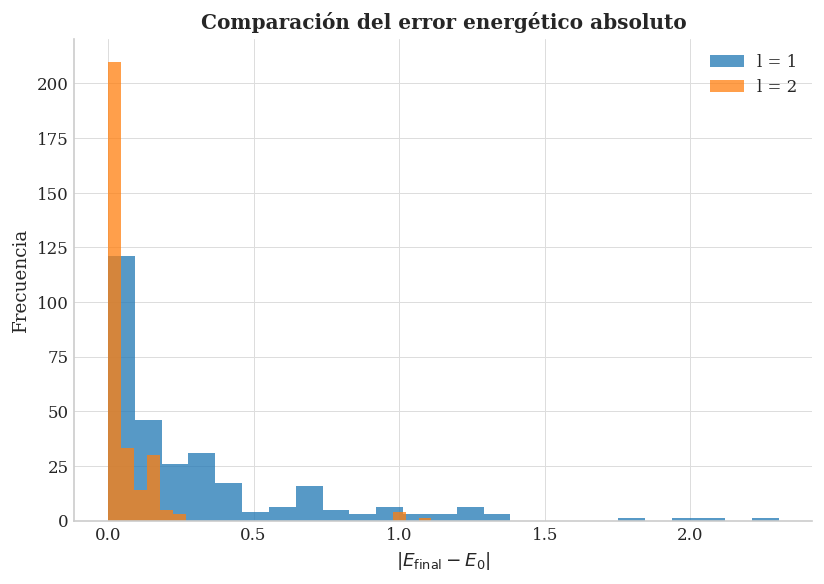

In [85]:
plt.figure(figsize=(7,5))

plt.hist(df1["diferencia_ground"], bins=25, alpha=0.75, label="l = 1")
plt.hist(df2["diferencia_ground"], bins=25, alpha=0.75, label="l = 2")

plt.xlabel(r"$|E_{\mathrm{final}} - E_0|$")
plt.ylabel("Frecuencia")
plt.title("Comparación del error energético absoluto")

plt.legend()
plt.tight_layout()
plt.show()

**Análisis:** `l=2` reduce drásticamente el error energético respecto a `l=1`. La media del error cae de $0.292$ a $0.056$ (5× menor) y la mediana de $0.151$ a $0.010$ (15× menor). Sin embargo, ambas distribuciones presentan una cola hacia errores grandes (máx. $2.30$ para `l=1` y $1.11$ para `l=2`), lo que indica que existen instancias difíciles que ninguno de los dos pools resuelve bien. El histograma de `l=2` está mucho más concentrado cerca de cero, pero no está exento de fallos ocasionales.

### 2. Función de distribución acumulada (CDF) del error

**Qué muestra:**
La fracción acumulada de instancias que alcanzan un error menor que un cierto umbral.

**Cómo interpretarlo:**
- Eje x (escala log): tolerancia energética.
- Eje y: proporción de grafos que cumplen esa tolerancia.
- Ejemplo:
  - Si en $10^{-3}$ la curva vale 0.8 → el 80% de las instancias tienen error menor que $10^{-3}$.

**Por qué es importante:**
Permite evaluar la **robustez del algoritmo** en todo el conjunto de instancias.

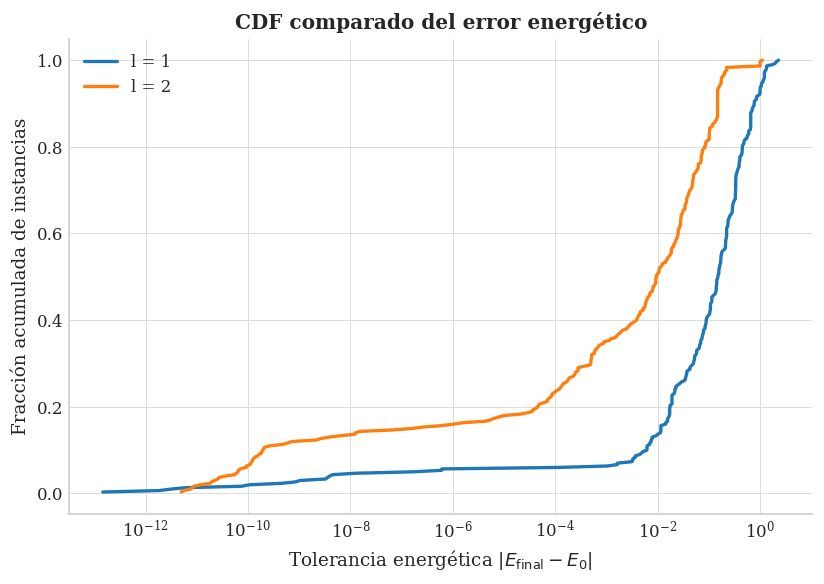

In [86]:
# Tomar errores absolutos
errors1 = np.sort(df1["diferencia_ground"].dropna().values)  # l = 1
cdf1 = np.arange(1, len(errors1) + 1) / len(errors1)

errors2 = np.sort(df2["diferencia_ground"].dropna().values)  # l = 2
cdf2 = np.arange(1, len(errors2) + 1) / len(errors2)

plt.figure(figsize=(7,5))

plt.plot(errors1, cdf1, label="l = 1")
plt.plot(errors2, cdf2, label="l = 2")

plt.xscale("log")
plt.xlabel(r"Tolerancia energética $|E_{\mathrm{final}} - E_0|$")
plt.ylabel("Fracción acumulada de instancias")
plt.title("CDF comparado del error energético")

plt.legend()
plt.tight_layout()
plt.show()

**Análisis:** La CDF confirma la ventaja sistemática de `l=2` en todo el rango de tolerancias. A tolerancia $10^{-2}$, `l=2` alcanza aproximadamente el 50% de los grafos mientras `l=1` apenas supera el 13%. La curva de `l=2` está desplazada consistentemente hacia la izquierda, lo que significa que para cualquier umbral de precisión exigido, `l=2` resuelve una mayor fracción de instancias. La brecha entre ambas curvas es especialmente pronunciada en tolerancias estrictas ($< 10^{-1}$), donde el pool extendido marca una diferencia real.


### 3. Distribución del número de iteraciones

**Qué muestra:**
Número de iteraciones (o tamaño del ansatz) que el algoritmo requiere para converger.

**Cómo interpretarlo:**
- Valores bajos → el algoritmo converge rápidamente.
- Distribuciones anchas → variabilidad en la dificultad de los grafos.
- Picos → comportamiento típico del algoritmo.

**Interpretación física:**
El número de iteraciones corresponde al número de operadores añadidos en ADAPT-VQE.

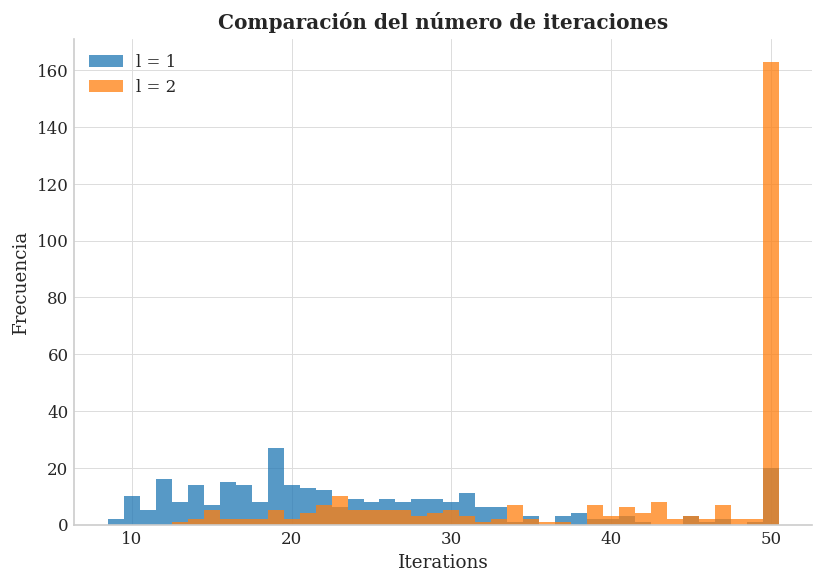

In [87]:
plt.figure(figsize=(7,5))

# bins comunes
min_iter = min(df1["iteraciones"].min(), df2["iteraciones"].min())
max_iter = max(df1["iteraciones"].max(), df2["iteraciones"].max())
bins = np.arange(min_iter, max_iter + 2) - 0.5

plt.hist(df1["iteraciones"], bins=bins, alpha=0.75, label="l = 1")
plt.hist(df2["iteraciones"], bins=bins, alpha=0.75, label="l = 2")

plt.xlabel("Iterations")
plt.ylabel("Frecuencia")
plt.title("Comparación del número de iteraciones")

plt.legend()
plt.tight_layout()
plt.show()

**Análisis:** `l=2` requiere significativamente más iteraciones para converger: media de $41.3$ frente a $24.2$ para `l=1`. Muchos grafos con `l=2` alcanzan el límite de 50 iteraciones sin converger, lo que sugiere que el pool extendido, si bien más expresivo, le cuesta más iteraciones encontrar la dirección correcta. `l=1`, con un pool más pequeño, converge de forma más consistente y predecible. Esto es relevante para evaluar la eficiencia real del algoritmo: la mayor precisión de `l=2` viene a costa de mayor profundidad del ansatz.

### 4. Curva promedio de convergencia del error energético

**Definición:**
$$
\Delta E_k = |E_k - E_0|
$$

**Qué muestra:**
La evolución del error energético a lo largo de las iteraciones del algoritmo.

**Componentes del gráfico:**
- Media → comportamiento promedio.
- Mediana → comportamiento típico.
- Banda (25%-75%) → variabilidad entre instancias.

**Cómo interpretarlo:**
- Disminución rápida → buena eficiencia inicial.
- Plateau → región donde el algoritmo deja de mejorar.
- Banda ancha → variabilidad entre grafos.

**Importancia:**
Este gráfico muestra la dinámica interna del algoritmo y su capacidad de convergencia.

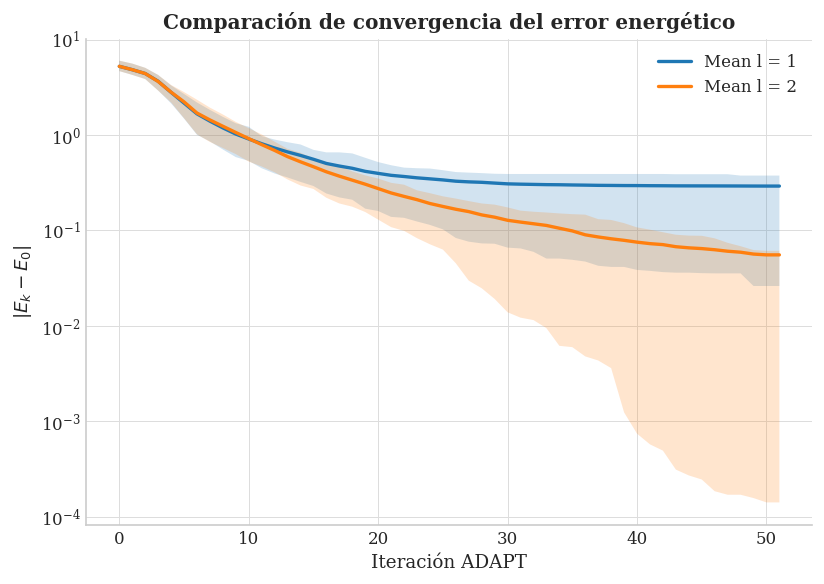

In [89]:
stats_l1 = compute_error_stats([
    "../resultados/json/resultados_completos_n6_l1_1_300.json"
])

stats_l2 = compute_error_stats([
    "../resultados/json/resultados_completos_n6_l2_1_300.json"
])

plt.figure(figsize=(7,5))

x1 = np.arange(stats_l1["len"])
x2 = np.arange(stats_l2["len"])

# medias
plt.plot(x1, stats_l1["mean"], label="Mean l = 1")
plt.plot(x2, stats_l2["mean"], label="Mean l = 2")

# bandas intercuartiles
plt.fill_between(x1, stats_l1["q25"], stats_l1["q75"], alpha=0.2)
plt.fill_between(x2, stats_l2["q25"], stats_l2["q75"], alpha=0.2)

plt.yscale("log")
plt.xlabel("Iteración ADAPT")
plt.ylabel(r"$|E_k - E_0|$")
plt.title("Comparación de convergencia del error energético")

plt.legend()
plt.tight_layout()
plt.show()

**Análisis:** Ambos algoritmos muestran una disminución inicial rápida del error promedio, seguida de un plateau. `l=2` alcanza errores promedio significativamente más bajos que `l=1` antes de estancarse, lo que confirma que el pool extendido converge a mejores mínimos. La banda intercuartil de `l=2` es más angosta en las últimas iteraciones, indicando menor variabilidad entre grafos una vez que el algoritmo ha avanzado. El plateau pronunciado en ambos casos hacia iteraciones altas sugiere retornos decrecientes: después de cierto punto, añadir operadores aporta cada vez menos mejora.

### 5. Razón de aproximación para Max-3-Cut

**Definición:**
$$
r = \frac{C_{\text{final}}}{C_{\max}} = \frac{E_{\text{final}}}{E_0} \in (0, 1]
$$
donde $C_{max}$ es el corte máximo exacto y $C_{final}$ es el corte obtenido por el algoritmo.

**Qué muestra:**
El histograma compara la distribución de la razón de aproximación entre `l=1` y `l=2`. El complemento de CDF muestra qué fracción de grafos alcanza un ratio **mayor o igual** a un umbral dado.

**Cómo interpretarlo:**
- $r = 1$ → solución exacta.
- $r \geq 0.99$ → solución dentro del 1% del óptimo.
- La curva **complemento de CDF más alta y a la derecha** corresponde al mejor algoritmo: a igual umbral, más grafos lo alcanzan.
- Esta métrica es más interpretable que el error absoluto porque está normalizada por el tamaño del problema y es directamente comparable con benchmarks de la literatura de optimización combinatoria.

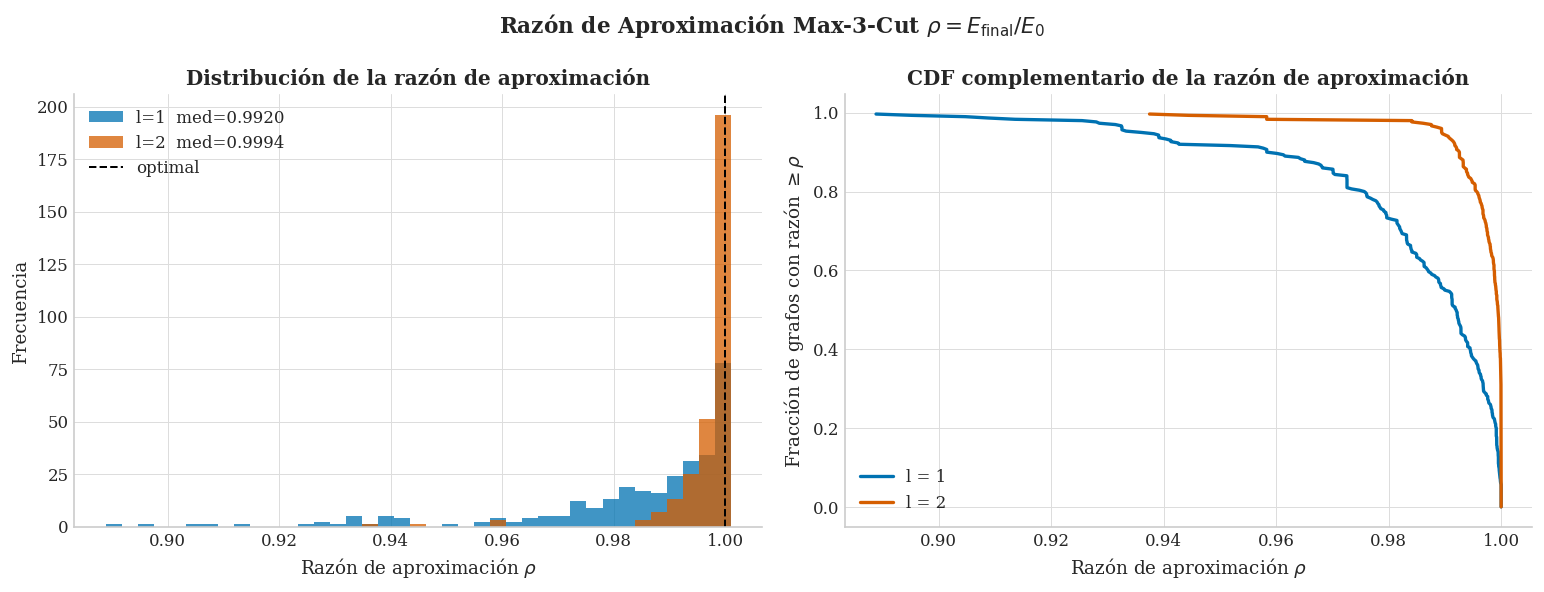

l=1 | media=0.98439  mediana=0.99202  min=0.88888
l=2 | media=0.99711  mediana=0.99945  min=0.93750

Grafos con ratio >= 0.99:  l=1 → 55.0%  |  l=2 → 94.7%


In [97]:
# Razón de aproximación para Max-3-Cut: C_final / C_max
# C_max = -E0 / 2,  C_final = -E_final / 2  →  ratio = E_final / E0

approx_ratio_l1 = np.array([
    data_l1[g]["final_energy"] / data_l1[g]["ground_energy"]
    for g in common_ids
])
approx_ratio_l2 = np.array([
    data_l2[g]["final_energy"] / data_l2[g]["ground_energy"]
    for g in common_ids
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramas comparados
ax = axes[0]
bins = np.linspace(min(approx_ratio_l1.min(), approx_ratio_l2.min()), 1.001, 40)
ax.hist(approx_ratio_l1, bins=bins, alpha=0.75, color=C1,
        label=f"l=1  med={np.median(approx_ratio_l1):.4f}")
ax.hist(approx_ratio_l2, bins=bins, alpha=0.75, color=C2,
        label=f"l=2  med={np.median(approx_ratio_l2):.4f}")
ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2, label="optimal")
ax.set_xlabel(r"Razón de aproximación $\rho$")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de la razón de aproximación")
ax.legend()

# CDF
ax = axes[1]
for ratio, label, color in [
    (approx_ratio_l1, "l = 1", C1),
    (approx_ratio_l2, "l = 2", C2),
]:
    sorted_r = np.sort(ratio)
    cdf = np.arange(1, len(sorted_r) + 1) / len(sorted_r)
    ax.plot(sorted_r, 1 - cdf, color=color, linewidth=2, label=label)

ax.set_xlabel(r"Razón de aproximación $\rho$")
ax.set_ylabel(r"Fracción de grafos con razón $\geq \rho$")
ax.set_title("CDF complementario de la razón de aproximación")
ax.legend()

plt.suptitle(r"Razón de Aproximación Max-3-Cut $\rho = E_{\mathrm{final}} / E_0$",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"l=1 | media={np.mean(approx_ratio_l1):.5f}  "
      f"mediana={np.median(approx_ratio_l1):.5f}  "
      f"min={np.min(approx_ratio_l1):.5f}")
print(f"l=2 | media={np.mean(approx_ratio_l2):.5f}  "
      f"mediana={np.median(approx_ratio_l2):.5f}  "
      f"min={np.min(approx_ratio_l2):.5f}")
print(f"\nGrafos con ratio >= 0.99:  l=1 → {np.mean(approx_ratio_l1 >= 0.99)*100:.1f}%  "
      f"|  l=2 → {np.mean(approx_ratio_l2 >= 0.99)*100:.1f}%")

**Análisis:** `l=2` logra una razón de aproximación mediana de $0.9994$ frente a $0.992$ de `l=1`, y el 94.7% de sus grafos alcanzan ratio $\geq 0.99$ versus solo el 55.0% de `l=1`. En términos del problema de optimización, `l=2` encuentra soluciones dentro del 1% del óptimo en prácticamente todos los grafos. `l=1` en cambio falla en casi la mitad de las instancias. El mínimo de `l=1` baja hasta $0.889$, lo que significa que algunos grafos solo alcanzan el 89% del corte óptimo, un margen no despreciable en un problema de optimización combinatoria.

### 6. Mejora marginal de energía por iteración

**Definición:**
$$
\Delta E_k = E_{k-1} - E_k \geq 0
$$
es la reducción de energía que aporta el $k$-ésimo operador añadido al ansatz.

**Qué muestra:**
La ganancia promedio (y su variabilidad) que cada nueva iteración de ADAPT produce. El eje y usa escala symlog para mostrar simultáneamente mejoras grandes y pequeñas.

**Cómo interpretarlo:**
- Las primeras iteraciones deberían tener $\Delta E_k$ grande: el algoritmo aprende rápido al principio.
- Un decaimiento rápido hacia cero indica **retornos decrecientes**: añadir más operadores deja de mejorar la solución.
- Si $\Delta E_k \approx 0$ antes de que el gradiente converja, el algoritmo está atascado en un mínimo local.
- Comparar `l=1` y `l=2`: si `l=2` tiene $\Delta E_k$ más grandes en las primeras iteraciones, el pool extendido da "mejores primeros pasos".

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24268\3181092007.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


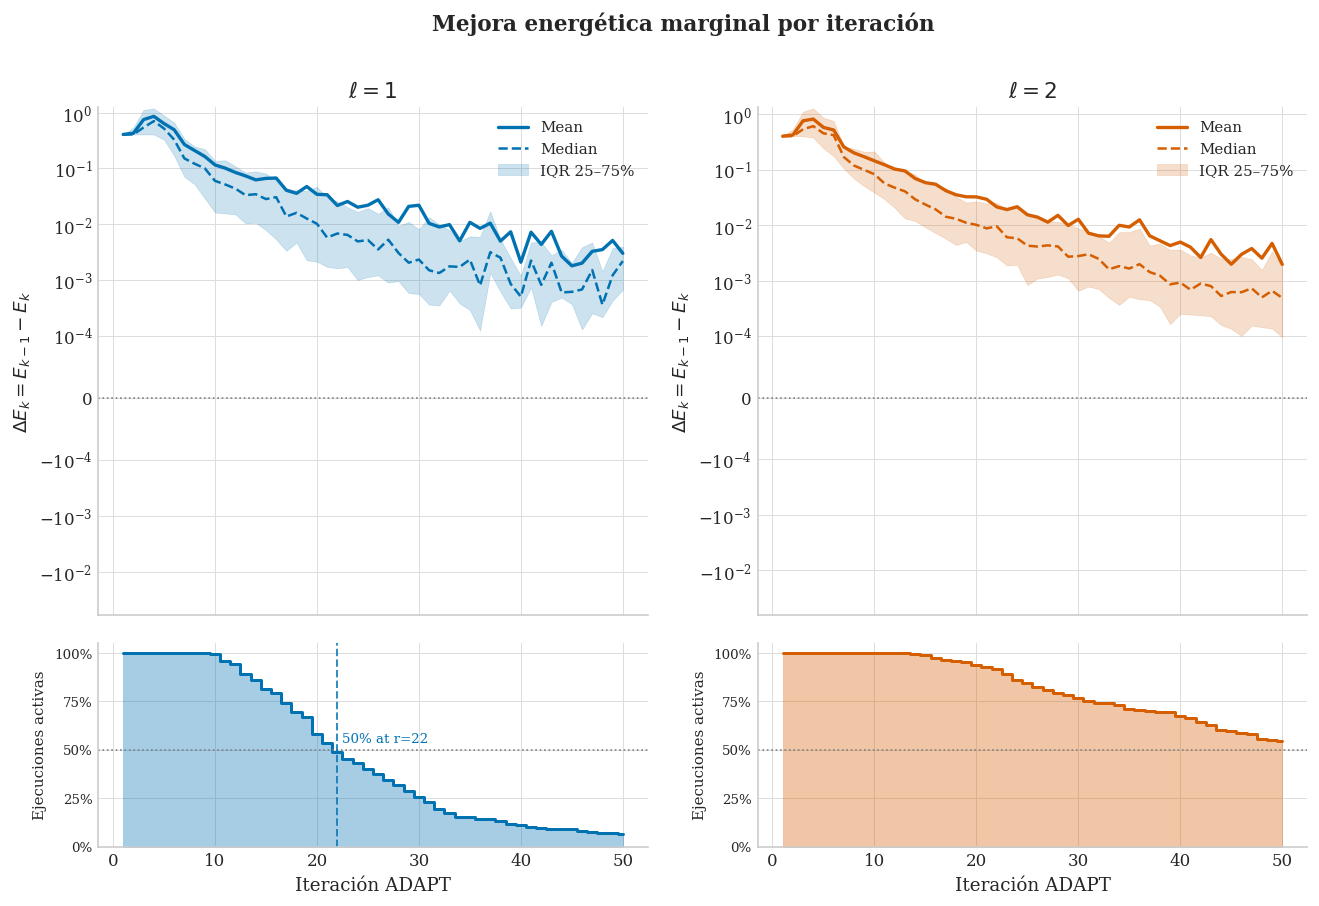

In [98]:
# Mejora marginal por iteracion + fraccion de runs activos (2 filas x 2 columnas)
def compute_marginal_stats(data_dict):
    all_deltas = []
    max_iters  = max(item['iterations'] for item in data_dict.values())
    for item in data_dict.values():
        trace  = np.array(item['energy_trace'], dtype=float)[:-1]
        deltas = np.diff(-trace)   # positivo cuando la energia baja
        all_deltas.append(deltas)
    padded = np.full((len(all_deltas), max_iters), np.nan)
    for i, d in enumerate(all_deltas):
        padded[i, :len(d)] = d
    n_active = np.sum(~np.isnan(padded), axis=0)
    return {
        'mean'    : np.nanmean(padded, axis=0),
        'median'  : np.nanmedian(padded, axis=0),
        'q25'     : np.nanpercentile(padded, 25, axis=0),
        'q75'     : np.nanpercentile(padded, 75, axis=0),
        'n_active': n_active,
        'frac_active': n_active / len(all_deltas),
    }

marg_l1 = compute_marginal_stats(data_l1)
marg_l2 = compute_marginal_stats(data_l2)
N_TOTAL = len(data_l1)   # 300

fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 8),
    gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08},
    sharex='col',
)

for col, (marg, label, color) in enumerate([
    (marg_l1, '$\ell = 1$', C1),
    (marg_l2, '$\ell = 2$', C2),
]):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]
    x = np.arange(1, len(marg['mean']) + 1)

    # ── Panel superior: mejora marginal ──
    ax_top.plot(x, marg['mean'],   color=color, linewidth=2,   label='Mean')
    ax_top.plot(x, marg['median'], color=color, linewidth=1.5,
                linestyle='--', label='Median')
    ax_top.fill_between(x, marg['q25'], marg['q75'],
                        color=color, alpha=0.20, label='IQR 25–75%')
    ax_top.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax_top.set_ylabel(r'$\Delta E_k = E_{k-1} - E_k$')
    ax_top.set_yscale('symlog', linthresh=1e-4)
    ax_top.set_title(label, fontsize=13)
    ax_top.legend(fontsize=9)
    ax_top.tick_params(labelbottom=False)

    # ── Panel inferior: fraccion de runs activos ──
    frac = marg['frac_active'] * 100   # porcentaje
    ax_bot.fill_between(x, 0, frac, color=color, alpha=0.35, step='mid')
    ax_bot.step(x, frac, color=color, linewidth=1.8, where='mid')
    ax_bot.axhline(50, color='gray', linestyle=':', linewidth=1)
    ax_bot.set_ylim(0, 105)
    ax_bot.set_yticks([0, 25, 50, 75, 100])
    ax_bot.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=8)
    ax_bot.set_ylabel('Ejecuciones activas', fontsize=9)
    ax_bot.set_xlabel('Iteración ADAPT')

    # Anotar donde cada pool pierde la mitad de sus runs
    half_iter = np.searchsorted(-frac, -50)
    if half_iter < len(x):
        ax_bot.axvline(x[half_iter], color=color, linewidth=1.2,
                       linestyle='--', alpha=0.8)
        ax_bot.text(x[half_iter] + 0.5, 54,
                    f'50% at r={x[half_iter]}',
                    fontsize=8, color=color)

fig.suptitle('Mejora energética marginal por iteración',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Análisis:** Ambos algoritmos exhiben retornos decrecientes claros: la mejora marginal $\Delta E_k$ es grande en las primeras iteraciones y decae rápidamente. Lo notable es que `l=2` mantiene mejoras marginales positivas durante más iteraciones antes de estancarse, lo que explica por qué llega a energías más bajas. `l=1` se aplana más rápido, consistente con su menor número de iteraciones. La banda intercuartil amplia en las primeras iteraciones indica alta variabilidad entre grafos en el primer "salto" de energía, mientras que en iteraciones tardías los grafos se comportan de forma más homogénea.

### 7. ¿Realmente usa `l=2` los operadores de $O_3$?

**Qué muestra:**
Para el pool `l=2`, que contiene operadores de $O_1$ y $O_3$, este análisis mide qué fracción de los operadores **efectivamente seleccionados** por ADAPT provienen de $O_3$ (los nuevos del pool extendido) versus $O_1$ (los que también tiene `l=1`).

**Cómo interpretarlo:**
- **Torta izquierda**: composición global del ansatz agregando los 300 grafos. Si $O_3$ tiene un porcentaje bajo, el pool extendido aporta poco en la práctica.
- **Histograma derecho**: distribución por grafo de la fracción de $O_3$ usada. Si la mayoría de grafos tiene fracción cercana a 0, significa que casi nunca se seleccionan operadores de $O_3$.
- Si la fracción media de $O_3$ es alta → `l=2` realmente explota el pool extendido.
- Si la fracción es baja → `l=2` converge usando principalmente los mismos operadores que `l=1`, y el beneficio del pool extendido es marginal.

**Por qué es importante:**
Esta es la pregunta central para justificar `l=2`: si el algoritmo no selecciona los operadores de $O_3$, el costo adicional del pool más grande no se traduce en mejora real.

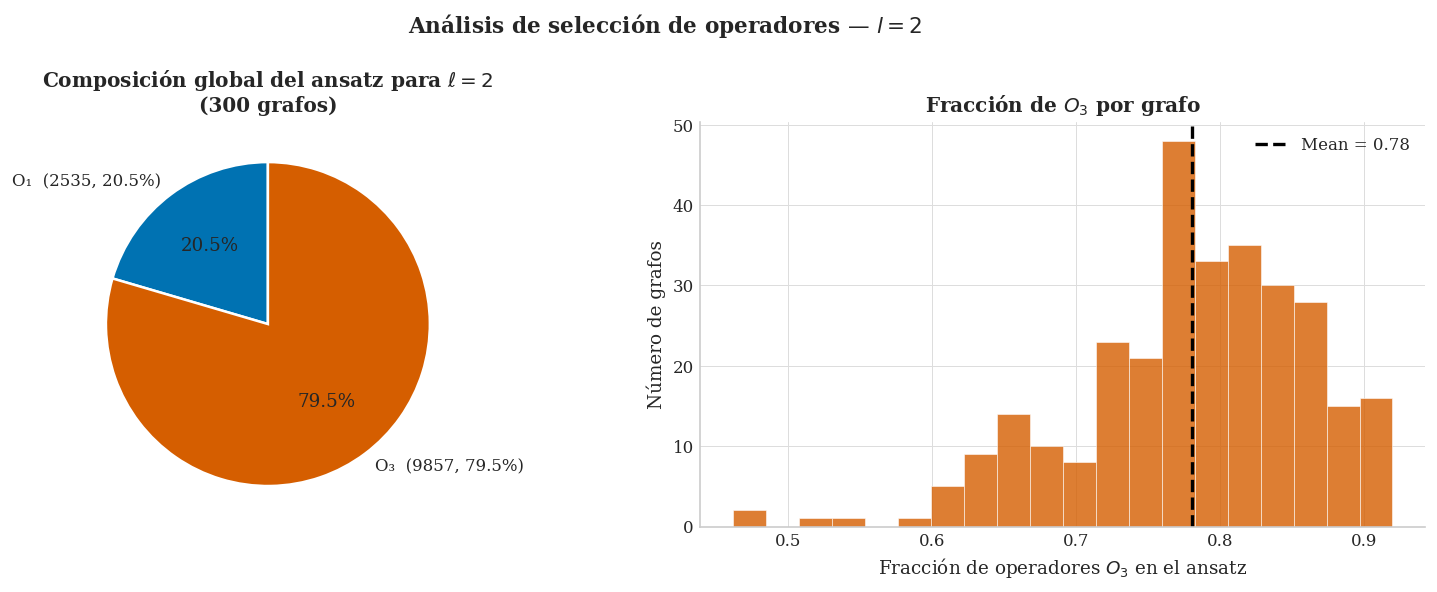

Total selecciones: 12392  |  O1: 2535 (20.5%)  |  O3: 9857 (79.5%)
Fracción media de O3 por grafo: 0.781  ±  0.080


In [100]:
# ¿Usa l=2 los operadores de O3? Análisis de selección de operadores
from collections import Counter

# Para cada grafo, los pool_labels de l=1 son exactamente los operadores de O1.
# En l=2, pool_labels = O1_labels + O3_labels.
# Comparamos los ansatz_op_labels de l=2 contra el pool de l=1 para clasificarlos.

count_o1, count_o3 = 0, 0
per_graph_frac_o3 = []

for gid in common_ids:
    pool_l1  = set(data_l1[gid].get("pool_labels", []))
    selected = data_l2[gid].get("ansatz_op_labels", [])

    n_o1 = sum(1 for lbl in selected if lbl in pool_l1)
    n_o3 = len(selected) - n_o1
    count_o1 += n_o1
    count_o3 += n_o3

    if len(selected) > 0:
        per_graph_frac_o3.append(n_o3 / len(selected))

per_graph_frac_o3 = np.array(per_graph_frac_o3)
total = count_o1 + count_o3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: torta global
ax = axes[0]
ax.pie([count_o1, count_o3],
       labels=[f"O₁  ({count_o1}, {100*count_o1/total:.1f}%)",
               f"O₃  ({count_o3}, {100*count_o3/total:.1f}%)"],
       colors=[C1, C2],
       autopct="%1.1f%%", startangle=90,
       wedgeprops=dict(edgecolor="white", linewidth=1.5))
ax.set_title("Composición global del ansatz para $\ell=2$\n(300 grafos)")

# Panel derecho: histograma de fracción de O3 por grafo
ax = axes[1]
ax.hist(per_graph_frac_o3, bins=20, color=C2, alpha=0.8, edgecolor="white")
ax.axvline(np.mean(per_graph_frac_o3), color="black", linestyle="--",
           label=f"Mean = {np.mean(per_graph_frac_o3):.2f}")
ax.set_xlabel("Fracción de operadores $O_3$ en el ansatz")
ax.set_ylabel("Número de grafos")
ax.set_title("Fracción de $O_3$ por grafo")
ax.legend()

plt.suptitle(r"Análisis de selección de operadores — $l=2$",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Total selecciones: {total}  |  O1: {count_o1} ({100*count_o1/total:.1f}%)  "
      f"|  O3: {count_o3} ({100*count_o3/total:.1f}%)")
print(f"Fracción media de O3 por grafo: {np.mean(per_graph_frac_o3):.3f}  "
      f"±  {np.std(per_graph_frac_o3):.3f}")

**Análisis:** Este es uno de los resultados más reveladores. En `l=2`, el **79.5%** de los operadores seleccionados por ADAPT provienen del pool $O_3$ (el pool extendido), con una fracción media por grafo de $0.78 \pm 0.08$. Esto significa que cuando se le da acceso al pool extendido, el algoritmo prefiere abrumadoramente los operadores de $O_3$ sobre los de $O_1$. El histograma por grafo muestra una distribución muy concentrada alrededor del 75-85%, con poca variabilidad entre instancias. Esto sugiere que los operadores de $O_3$ tienen gradientes sistemáticamente más altos que los de $O_1$ en las condiciones del problema, lo que los hace más "atractivos" para ADAPT en cada paso. La implicación práctica es que `l=1` y `l=2` están recorriendo caminos completamente distintos en el espacio de operadores.

### 8. Distribución de los parámetros optimizados $\theta$

**Qué muestra:**
El histograma de todos los valores $\theta_k$ finales del ansatz, recolectados sobre los 300 grafos.

**Cómo interpretarlo:**
- Una distribución concentrada alrededor de un valor específico sugiere que el algoritmo converge a una estructura de ansatz **universal**, independiente del grafo.
- Una distribución muy dispersa indica que los parámetros varían mucho entre instancias, lo que implica mayor dificultad de generalización.
- Si `l=1` y `l=2` tienen distribuciones similares, los operadores adicionales de $O_3$ no cambian el perfil de los ángulos seleccionados.
- Valores concentrados cerca de cero pueden indicar que algunos operadores son redundantes.

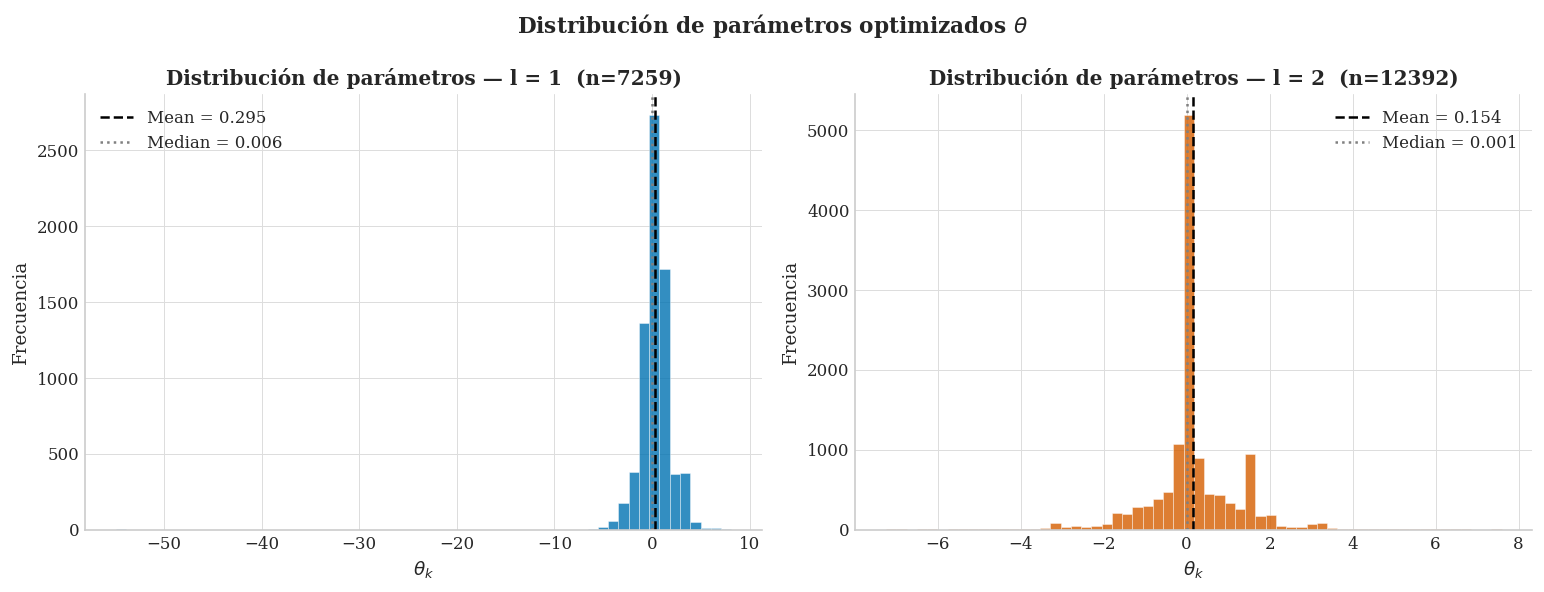

l=1 | media=0.2948  std=1.5950  min=-54.9524  max=8.1304
l=2 | media=0.1541  std=1.0052  min=-7.2444  max=7.5920


In [103]:
# Distribución de los parámetros theta finales
all_params_l1, all_params_l2 = [], []

for item in data_l1.values():
    all_params_l1.extend(item.get("params", []))
for item in data_l2.values():
    all_params_l2.extend(item.get("params", []))

all_params_l1 = np.array(all_params_l1)
all_params_l2 = np.array(all_params_l2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, params, label, color in [
    (axes[0], all_params_l1, "l = 1", C1),
    (axes[1], all_params_l2, "l = 2", C2),
]:
    ax.hist(params, bins=60, color=color, alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(np.mean(params),   color="black", linestyle="--", linewidth=1.5,
               label=f"Mean = {np.mean(params):.3f}")
    ax.axvline(np.median(params), color="gray",  linestyle=":",  linewidth=1.5,
               label=f"Median = {np.median(params):.3f}")
    ax.set_xlabel(r"$\theta_k$")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Distribución de parámetros — {label}  (n={len(params)})")
    ax.legend()

plt.suptitle(r"Distribución de parámetros optimizados $\theta$",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"l=1 | media={np.mean(all_params_l1):.4f}  "
      f"std={np.std(all_params_l1):.4f}  "
      f"min={np.min(all_params_l1):.4f}  max={np.max(all_params_l1):.4f}")
print(f"l=2 | media={np.mean(all_params_l2):.4f}  "
      f"std={np.std(all_params_l2):.4f}  "
      f"min={np.min(all_params_l2):.4f}  max={np.max(all_params_l2):.4f}")

**Análisis:** El pico pronunciado en $\theta \approx 0$ es un comportamiento **esperado y sano** del algoritmo ADAPT. No indica que los operadores sean redundantes, sino que refleja la **estructura jerárquica del ansatz**: los primeros operadores hacen el trabajo pesado (ángulos grandes) y los siguientes solo aplican correcciones finas (ángulos pequeños). Además, BFGS re-optimiza *todos* los parámetros simultáneamente en cada iteración, por lo que un parámetro que era grande puede volverse pequeño cuando un operador posterior toma su lugar en la dirección de descenso. La presencia de muchos $\theta \approx 0$ solo sería problemática si los operadores con ángulo cero fueran también los últimos en agregarse, lo que indicaría que el algoritmo continúa iterando sin aportar mejoras reales (problema de umbral $\varepsilon$).

La diferencia más relevante entre los dos pools es la **cola izquierda de `l=1`** (mín. $-54.95$ vs. $-7.24$ de `l=2`). Los operadores de $O_1$ tienen un paisaje de optimización más plano y periódico: BFGS puede desplazarse grandes distancias sin penalización, lo que en algunos grafos lleva a ángulos extremadamente grandes que pueden corresponder a mínimos locales. `l=2`, al incluir operadores de $O_3$ que apuntan directamente en la dirección de descenso cuántico, encuentra ángulos más pequeños y consistentes (std $=1.01$ vs. $1.60$), lo que refleja un paisaje de optimización más regular.

## Análisis: presupuesto común

Para hacer una comparación justa entre `l=1` y `l=2`, se iguala el número de iteraciones de ambos al del algoritmo que converge primero: para cada grafo se calcula $r_{common} = \min(r_{l=1}, r_{l=2})$ y se truncan las trazas de ambos en ese punto. Así, si `l=1` converge en 20 iteraciones y `l=2` en 44, ambos son evaluados con solo 20 operadores en el ansatz — esto elimina la ventaja artificial que tendría el algoritmo que usa más iteraciones.

A diferencia del caso normal (donde cada algoritmo corre hasta su propia convergencia), aquí el que converge antes "detiene" al otro. Los análisis a continuación son idénticos a los del caso normal, pero sobre los datos truncados.

### 0. Carga de datos

In [90]:
from pathlib import Path

# ============================================================
# ARCHIVOS DE SALIDA
# ============================================================

OUTPUT_L1_CSV = Path("../resultados/csv/resultados_resumen_n6_l1_common_budget.csv")
OUTPUT_L1_JSON = Path("../resultados/json/resultados_completos_n6_l1_common_budget.json")

OUTPUT_L2_CSV = Path("../resultados/csv/resultados_resumen_n6_l2_common_budget.csv")
OUTPUT_L2_JSON = Path("../resultados/json/resultados_completos_n6_l2_common_budget.json")


# ============================================================
# EJECUCIÓN PRINCIPAL
# ============================================================

# Reutilizamos data_l1/data_l2 (JSON completos sin restricción) ya
# cargados en "Análisis: convergencia libre" — evita releer los mismos
# archivos de nuevo.
l1_by_id = data_l1
l2_by_id = data_l2

controlled_l1 = []
controlled_l2 = []
budget_info = []
errors = []

for grafo_id in sorted(l1_by_id.keys()):

    if grafo_id not in l2_by_id:
        error_msg = f"No se encontró grafo_id={grafo_id} en l=2."

        controlled_l1.append({
            "grafo_id": grafo_id,
            "error": error_msg
        })

        controlled_l2.append({
            "grafo_id": grafo_id,
            "error": error_msg
        })

        errors.append((grafo_id, error_msg))
        continue

    try:
        r_l1 = get_num_ops(l1_by_id[grafo_id])
        r_l2 = get_num_ops(l2_by_id[grafo_id])

        r_common = min(r_l1, r_l2)

        item_l1 = truncate_result_to_budget(
            result=l1_by_id[grafo_id],
            r_common=r_common
        )

        item_l2 = truncate_result_to_budget(
            result=l2_by_id[grafo_id],
            r_common=r_common
        )

        item_l1["grafo_id"] = grafo_id
        item_l2["grafo_id"] = grafo_id

        controlled_l1.append(item_l1)
        controlled_l2.append(item_l2)

        budget_info.append({
            "grafo_id": grafo_id,
            "r_l1_original": r_l1,
            "r_l2_original": r_l2,
            "r_common": r_common
        })

    except Exception as e:
        error_msg = str(e)

        controlled_l1.append({
            "grafo_id": grafo_id,
            "error": error_msg
        })

        controlled_l2.append({
            "grafo_id": grafo_id,
            "error": error_msg
        })

        errors.append((grafo_id, error_msg))


# ============================================================
# GUARDAR ARCHIVOS
# ============================================================

save_json(controlled_l1, OUTPUT_L1_JSON)
save_json(controlled_l2, OUTPUT_L2_JSON)

save_csv(controlled_l1, OUTPUT_L1_CSV)
save_csv(controlled_l2, OUTPUT_L2_CSV)


# ============================================================
# VERIFICACIÓN
# ============================================================

mismatches = []

for item_l1, item_l2 in zip(controlled_l1, controlled_l2):

    if "error" in item_l1 or "error" in item_l2:
        continue

    if int(item_l1["iterations"]) != int(item_l2["iterations"]):
        mismatches.append(
            (
                item_l1["grafo_id"],
                item_l1["iterations"],
                item_l2["iterations"]
            )
        )

print("\nArchivos guardados:")
print(f"  {OUTPUT_L1_CSV}")
print(f"  {OUTPUT_L1_JSON}")
print(f"  {OUTPUT_L2_CSV}")
print(f"  {OUTPUT_L2_JSON}")

print(f"\nResultados procesados: {len(controlled_l1)}")
print(f"Errores: {len(errors)}")

if errors:
    print("\nPrimeros errores:")
    for err in errors[:20]:
        print(err)

if len(mismatches) == 0:
    print("\nVerificación correcta: l=1 y l=2 tienen las mismas iteraciones por grafo.")
else:
    print("\nHay diferencias en iteraciones:")
    for item in mismatches[:20]:
        print(item)

print("\nPrimeros presupuestos comunes:")
for item in budget_info[:10]:
    print(item)

# ============================================================
# ESTRUCTURAS EN MEMORIA (evita releer los archivos recien guardados)
# ============================================================

data_l1 = {item["grafo_id"]: item for item in controlled_l1 if "error" not in item}
data_l2 = {item["grafo_id"]: item for item in controlled_l2 if "error" not in item}

def _resumen_row(item):
    return {
        "grafo_id": item["grafo_id"],
        "num_edges": item["num_edges"],
        "ground_energy": item["ground_energy"],
        "iteraciones": item["iterations"],
        "energia_final": item["final_energy"],
        "diferencia_ground": item["difference_ground"],
        "gradiente_final": item["final_gradient_norm"],
        "runtime_min": item["runtime_min"],
        "initial_energy": item["initial_energy"],
    }

df1_controled = pd.DataFrame([_resumen_row(item) for item in controlled_l1 if "error" not in item])
df2_controled = pd.DataFrame([_resumen_row(item) for item in controlled_l2 if "error" not in item])


Archivos guardados:
  resultados\csv\resultados_resumen_n6_l1_common_budget.csv
  resultados\json\resultados_completos_n6_l1_common_budget.json
  resultados\csv\resultados_resumen_n6_l2_common_budget.csv
  resultados\json\resultados_completos_n6_l2_common_budget.json

Resultados procesados: 300
Errores: 0

Verificación correcta: l=1 y l=2 tienen las mismas iteraciones por grafo.

Primeros presupuestos comunes:
{'grafo_id': 1, 'r_l1_original': 20, 'r_l2_original': 44, 'r_common': 20}
{'grafo_id': 2, 'r_l1_original': 12, 'r_l2_original': 34, 'r_common': 12}
{'grafo_id': 3, 'r_l1_original': 12, 'r_l2_original': 50, 'r_common': 12}
{'grafo_id': 4, 'r_l1_original': 21, 'r_l2_original': 27, 'r_common': 21}
{'grafo_id': 5, 'r_l1_original': 20, 'r_l2_original': 30, 'r_common': 20}
{'grafo_id': 6, 'r_l1_original': 33, 'r_l2_original': 50, 'r_common': 33}
{'grafo_id': 7, 'r_l1_original': 15, 'r_l2_original': 50, 'r_common': 15}
{'grafo_id': 8, 'r_l1_original': 19, 'r_l2_original': 50, 'r_common

l=1 stopped first: 259/300 (86.3%)
l=2 stopped first: 19/300 (6.3%)
Tied (incl. both hit r_max=50): 22/300 (7.3%)


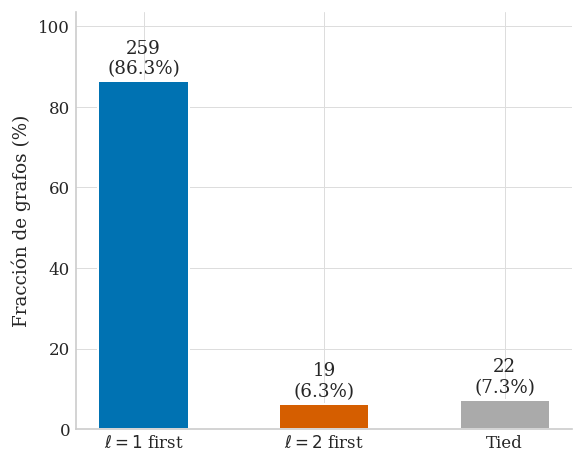

In [92]:
# Who set the common budget?
# Use df1 and df2 (original unrestricted data) to compare actual iteration counts
iters_l1 = df1.sort_values('grafo_id')['iteraciones'].values
iters_l2 = df2.sort_values('grafo_id')['iteraciones'].values
N = len(iters_l1)

n_l1_first = int(np.sum(iters_l1 < iters_l2))
n_l2_first = int(np.sum(iters_l2 < iters_l1))
n_tie      = int(np.sum(iters_l1 == iters_l2))

print(f'l=1 stopped first: {n_l1_first}/{N} ({100*n_l1_first/N:.1f}%)')
print(f'l=2 stopped first: {n_l2_first}/{N} ({100*n_l2_first/N:.1f}%)')
print(f'Tied (incl. both hit r_max=50): {n_tie}/{N} ({100*n_tie/N:.1f}%)')

labels = [r'$\ell=1$ first', r'$\ell=2$ first', 'Tied']
counts = [n_l1_first, n_l2_first, n_tie]
colors = [C1, C2, '#AAAAAA']

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, [100*c/N for c in counts], color=colors,
              edgecolor='white', linewidth=1.2, width=0.5)

for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'{c}\n({100*c/N:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Fracción de grafos (%)')
ax.set_ylim(0, max(100*c/N for c in counts) * 1.20)
#x.set_title('Pool que converge primero (presupuesto común)')
plt.tight_layout()
plt.show()

**Análisis:** Con presupuesto común, ambos algoritmos usan exactamente el mismo número de iteraciones por grafo (el mínimo entre los dos), lo que hace la comparación estrictamente justa. La distribución resultante refleja la convergencia de `l=1`, que es el algoritmo más rápido en casi todos los grafos (media $24.2$ vs $41.3$). Esto implica que `l=2` es evaluado antes de completar su convergencia natural.

### 1. Distribución del error energético absoluto — Presupuesto común

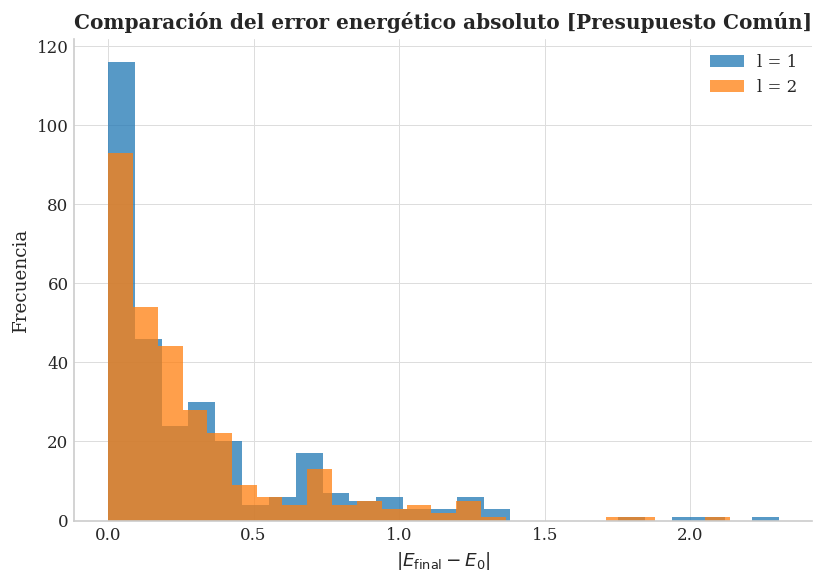

In [93]:
plt.figure(figsize=(7,5))

plt.hist(df1_controled["diferencia_ground"], bins=25, alpha=0.75, label="l = 1")
plt.hist(df2_controled["diferencia_ground"], bins=25, alpha=0.75, label="l = 2")

plt.xlabel(r"$|E_{\mathrm{final}} - E_0|$")
plt.ylabel("Frecuencia")
plt.title("Comparación del error energético absoluto [Presupuesto Común]")

plt.legend()
plt.tight_layout()
plt.show()

**Análisis:** Al igualar el presupuesto de iteraciones, las distribuciones de error de `l=1` y `l=2` se vuelven muy similares. La ventaja de `l=2` observada en el caso normal prácticamente desaparece, lo que revela que su mayor precisión no proviene de una superioridad intrínseca por iteración, sino del hecho de usar más iteraciones.

### 2. Función de distribución acumulada (CDF) del error — Presupuesto común

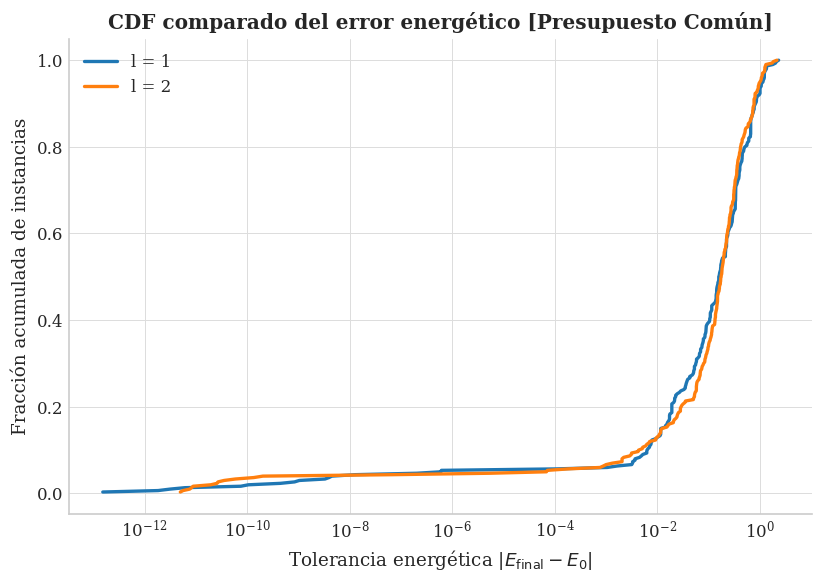

In [94]:
# Tomar errores absolutos
errors1 = np.sort(df1_controled["diferencia_ground"].dropna().values)  # l = 1
cdf1 = np.arange(1, len(errors1) + 1) / len(errors1)

errors2 = np.sort(df2_controled["diferencia_ground"].dropna().values)  # l = 2
cdf2 = np.arange(1, len(errors2) + 1) / len(errors2)

plt.figure(figsize=(7,5))

plt.plot(errors1, cdf1, label="l = 1")
plt.plot(errors2, cdf2, label="l = 2")

plt.xscale("log")
plt.xlabel(r"Tolerancia energética $|E_{\mathrm{final}} - E_0|$")
plt.ylabel("Fracción acumulada de instancias")
plt.title("CDF comparado del error energético [Presupuesto Común]")

plt.legend()
plt.tight_layout()
plt.show()

**Análisis:** La CDF con presupuesto común confirma el empate entre `l=1` y `l=2`: ambas curvas se superponen casi perfectamente en todo el rango de tolerancias. Esto contrasta fuertemente con el caso normal, donde `l=2` dominaba ampliamente. El resultado es contundente: per iteración, `l=1` y `l=2` son equivalentes.

### 4. Curva promedio de convergencia del error energético — Presupuesto común

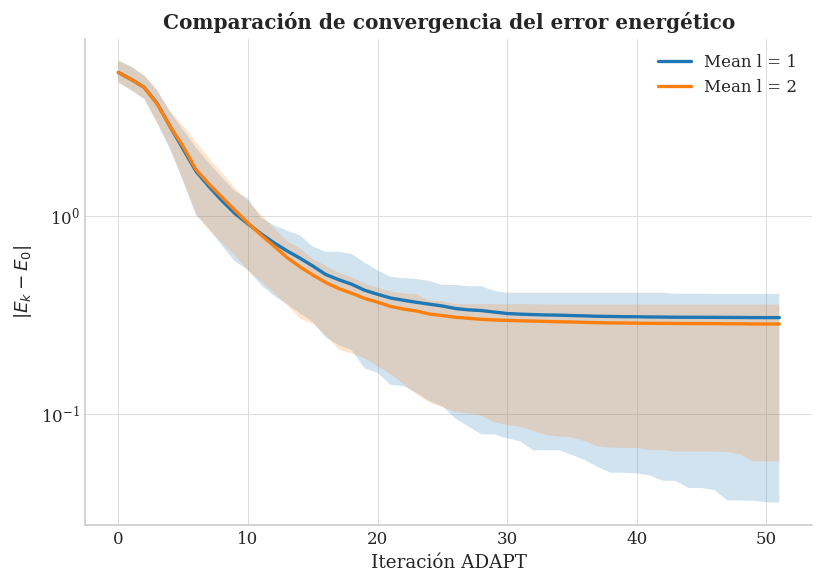

In [95]:
stats_l1 = compute_error_stats([
    "../resultados/json/resultados_completos_n6_l1_common_budget.json"
])

stats_l2 = compute_error_stats([
    "../resultados/json/resultados_completos_n6_l2_common_budget.json"
])

plt.figure(figsize=(7,5))

x1 = np.arange(stats_l1["len"])
x2 = np.arange(stats_l2["len"])

# medias
plt.plot(x1, stats_l1["mean"], label="Mean l = 1")
plt.plot(x2, stats_l2["mean"], label="Mean l = 2")

# bandas intercuartiles
plt.fill_between(x1, stats_l1["q25"], stats_l1["q75"], alpha=0.2)
plt.fill_between(x2, stats_l2["q25"], stats_l2["q75"], alpha=0.2)

plt.yscale("log")
plt.xlabel("Iteración ADAPT")
plt.ylabel(r"$|E_k - E_0|$")
plt.title("Comparación de convergencia del error energético")

plt.legend()
plt.tight_layout()
plt.show()

**Análisis:** Con presupuesto común, las curvas de convergencia de `l=1` y `l=2` se solapan casi perfectamente, en contraste con el caso normal donde `l=2` llegaba a errores menores. Esto confirma que la diferencia de calidad entre ambos pools surge únicamente en iteraciones tardías, a las que `l=2` llega pero `l=1` no necesita porque ya convergió. En el rango de iteraciones donde ambos compiten, son indistinguibles.

### 5. Razón de aproximación — Presupuesto común

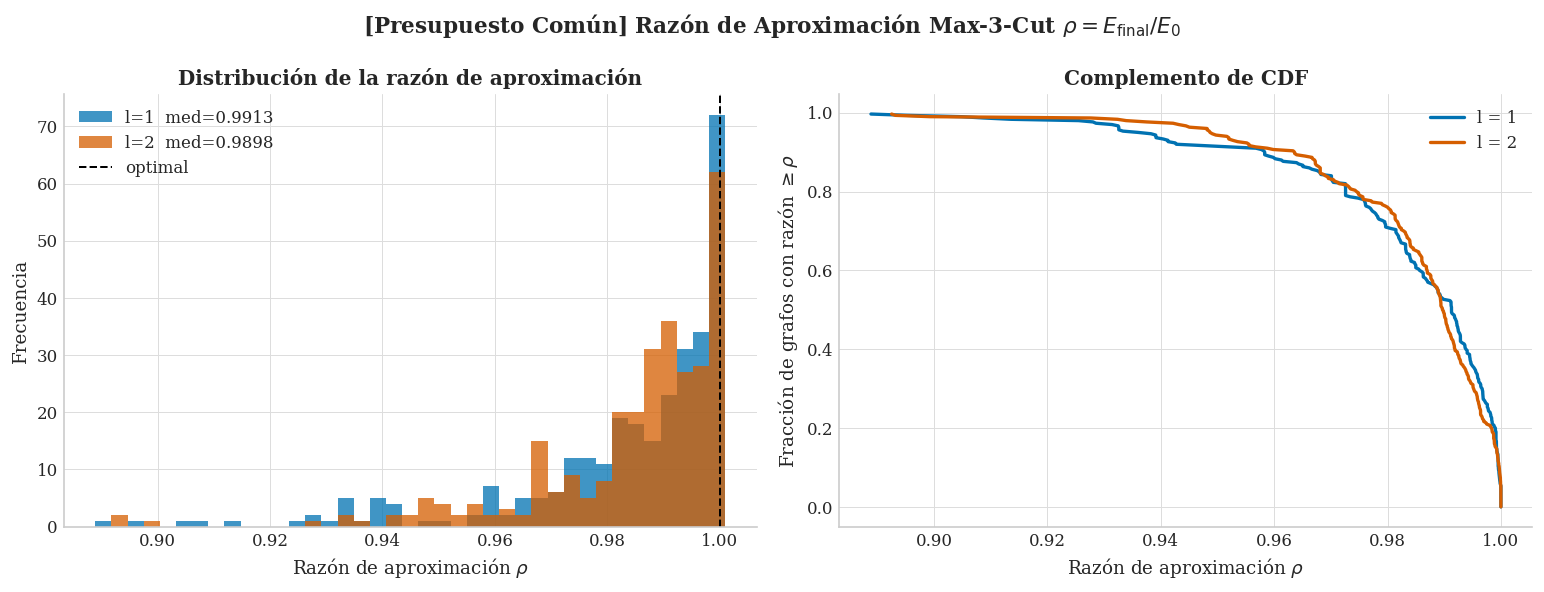

Grafos con ratio >= 0.99:  l=1 → 52.7%  |  l=2 → 49.3%


In [105]:
# [Presupuesto común] Razón de aproximación
approx_ratio_l1 = np.array([data_l1[g]["final_energy"] / data_l1[g]["ground_energy"] for g in common_ids])
approx_ratio_l2 = np.array([data_l2[g]["final_energy"] / data_l2[g]["ground_energy"] for g in common_ids])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
bins = np.linspace(min(approx_ratio_l1.min(), approx_ratio_l2.min()), 1.001, 40)
ax.hist(approx_ratio_l1, bins=bins, alpha=0.75, color=C1,
        label=f"l=1  med={np.median(approx_ratio_l1):.4f}")
ax.hist(approx_ratio_l2, bins=bins, alpha=0.75, color=C2,
        label=f"l=2  med={np.median(approx_ratio_l2):.4f}")
ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2, label="optimal")
ax.set_xlabel(r"Razón de aproximación $\rho$"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de la razón de aproximación"); ax.legend()

ax = axes[1]
for ratio, label, color in [(approx_ratio_l1, "l = 1", C1), (approx_ratio_l2, "l = 2", C2)]:
    sorted_r = np.sort(ratio)
    ax.plot(sorted_r, 1 - np.arange(1, len(sorted_r)+1)/len(sorted_r), color=color, linewidth=2, label=label)
ax.set_xlabel(r"Razón de aproximación $\rho$")
ax.set_ylabel(r"Fracción de grafos con razón $\geq \rho$")
ax.set_title("Complemento de CDF"); ax.legend()

plt.suptitle(r"[Presupuesto Común] Razón de Aproximación Max-3-Cut $\rho = E_{\mathrm{final}} / E_0$",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Grafos con ratio >= 0.99:  l=1 → {np.mean(approx_ratio_l1 >= 0.99)*100:.1f}%  "
      f"|  l=2 → {np.mean(approx_ratio_l2 >= 0.99)*100:.1f}%")

**Análisis:** Con el mismo presupuesto de iteraciones, la ventaja de `l=2` colapsa: solo el 49.3% de sus grafos alcanzan ratio $\geq 0.99$, prácticamente igual al 52.7% de `l=1`. Comparado con el caso normal (94.7% vs 55%), esto demuestra que **la superioridad de `l=2` es puramente una consecuencia de usar más iteraciones**, no de una mayor calidad por iteración.

### 6. Mejora marginal por iteración — Presupuesto común

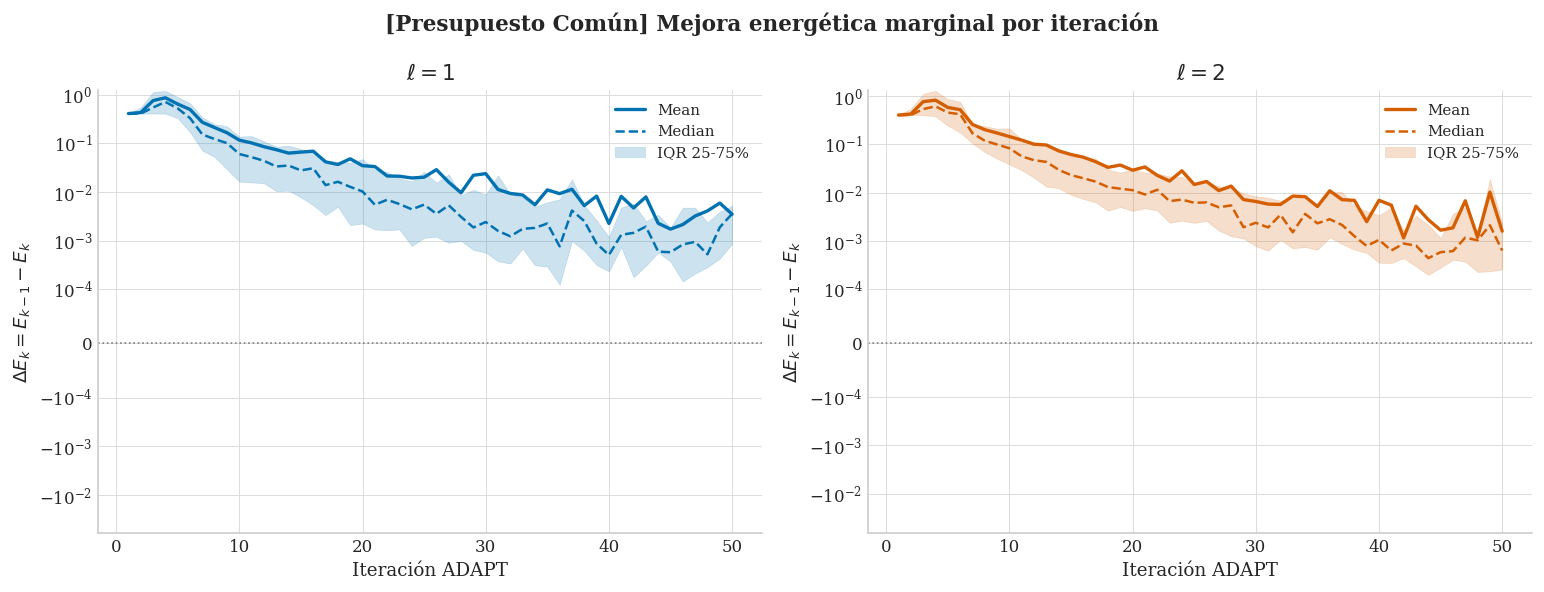

In [106]:
# [Presupuesto comun] Mejora marginal por iteracion (solo panel superior)
def compute_marginal_stats_cb(data_dict, r_common_dict):
    all_deltas = []
    max_iters  = max(r_common_dict.values())
    for g, item in data_dict.items():
        r_cut = r_common_dict[g]
        trace  = np.array(item['energy_trace'], dtype=float)[:-1]
        trace  = trace[:r_cut + 1]   # truncar al presupuesto comun
        deltas = np.diff(-trace)
        all_deltas.append(deltas)
    padded = np.full((len(all_deltas), max_iters), np.nan)
    for i, d in enumerate(all_deltas):
        padded[i, :len(d)] = d
    n_active = np.sum(~np.isnan(padded), axis=0)
    return {
        'mean'        : np.nanmean(padded, axis=0),
        'median'      : np.nanmedian(padded, axis=0),
        'q25'         : np.nanpercentile(padded, 25, axis=0),
        'q75'         : np.nanpercentile(padded, 75, axis=0),
        'n_active'    : n_active,
        'frac_active' : n_active / len(all_deltas),
    }

r_common = {g: min(data_l1[g]['iterations'], data_l2[g]['iterations']) for g in common_ids}
marg_l1_cb = compute_marginal_stats_cb(data_l1, r_common)
marg_l2_cb = compute_marginal_stats_cb(data_l2, r_common)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for col, (marg, label, color) in enumerate([
    (marg_l1_cb, '$\ell = 1$', C1),
    (marg_l2_cb, '$\ell = 2$', C2),
]):
    ax = axes[col]
    x = np.arange(1, len(marg['mean']) + 1)

    ax.plot(x, marg['mean'],   color=color, linewidth=2,   label='Mean')
    ax.plot(x, marg['median'], color=color, linewidth=1.5,
            linestyle='--', label='Median')
    ax.fill_between(x, marg['q25'], marg['q75'],
                    color=color, alpha=0.20, label='IQR 25-75%')
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_ylabel(r'$\Delta E_k = E_{k-1} - E_k$')
    ax.set_yscale('symlog', linthresh=1e-4)
    ax.set_title(label, fontsize=13)
    ax.legend(fontsize=9)
    ax.set_xlabel('Iteración ADAPT')

fig.suptitle('[Presupuesto Común] Mejora energética marginal por iteración',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Análisis:** Con presupuesto común, las curvas de mejora marginal de `l=1` y `l=2` son casi idénticas. Esto confirma que por cada iteración, ambos pools producen mejoras de energía equivalentes. La diferencia del caso normal se debe enteramente al mayor número de iteraciones que realiza `l=2`.

### 7. ¿Usa `l=2` los operadores de $O_3$? — Presupuesto común

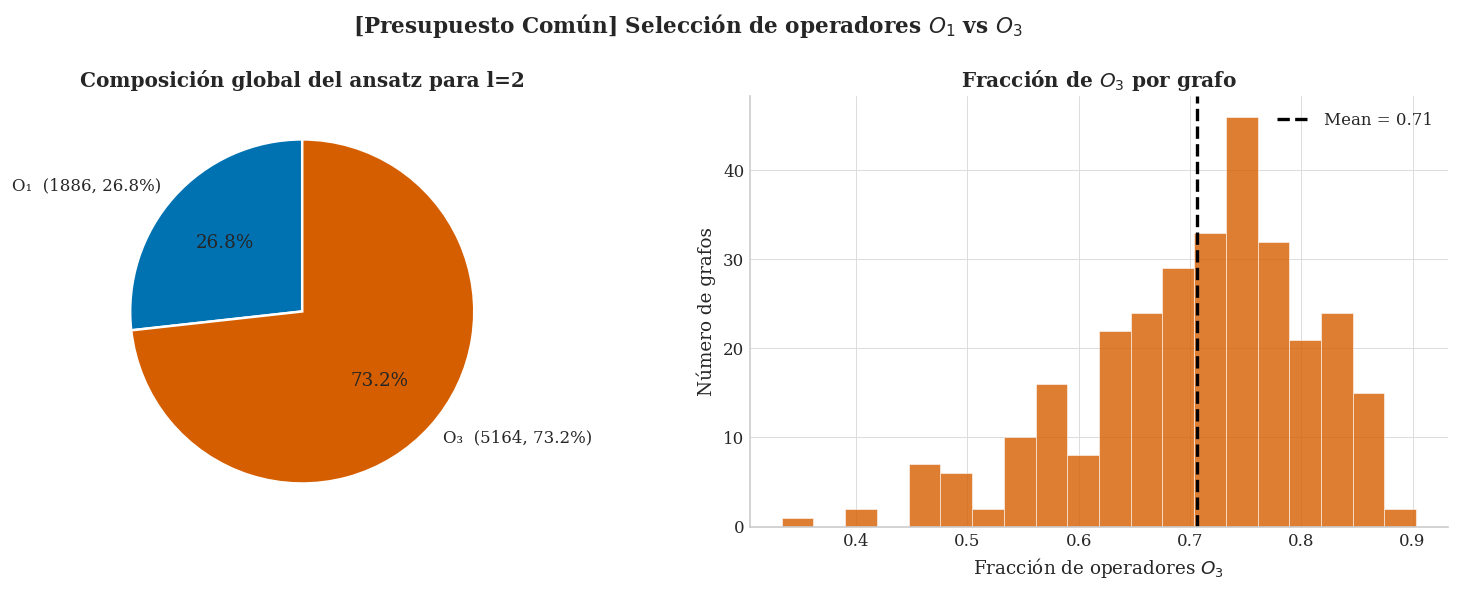

O1: 1886 (26.8%)  |  O3: 5164 (73.2%)


In [108]:
# [Presupuesto común] ¿Usa l=2 los operadores de O3?
from collections import Counter
count_o1, count_o3 = 0, 0
per_graph_frac_o3 = []

for gid in common_ids:
    pool_l1_set = set(data_l1[gid].get("pool_labels", []))
    selected    = data_l2[gid].get("ansatz_op_labels", [])
    n_o1 = sum(1 for lbl in selected if lbl in pool_l1_set)
    n_o3 = len(selected) - n_o1
    count_o1 += n_o1; count_o3 += n_o3
    if len(selected) > 0:
        per_graph_frac_o3.append(n_o3 / len(selected))

per_graph_frac_o3 = np.array(per_graph_frac_o3)
total = count_o1 + count_o3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie([count_o1, count_o3],
            labels=[f"O₁  ({count_o1}, {100*count_o1/total:.1f}%)",
                    f"O₃  ({count_o3}, {100*count_o3/total:.1f}%)"],
            colors=[C1, C2], autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[0].set_title("Composición global del ansatz para l=2")

axes[1].hist(per_graph_frac_o3, bins=20, color=C2, alpha=0.8, edgecolor="white")
axes[1].axvline(np.mean(per_graph_frac_o3), color="black", linestyle="--",
                label=f"Mean = {np.mean(per_graph_frac_o3):.2f}")
axes[1].set_xlabel("Fracción de operadores $O_3$"); axes[1].set_ylabel("Número de grafos")
axes[1].set_title("Fracción de $O_3$ por grafo"); axes[1].legend()

plt.suptitle("[Presupuesto Común] Selección de operadores $O_1$ vs $O_3$", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"O1: {count_o1} ({100*count_o1/total:.1f}%)  |  O3: {count_o3} ({100*count_o3/total:.1f}%)")

**Análisis:** Con presupuesto común la proporción de $O_3$ baja levemente de 79.5% a 73.2%, pero sigue siendo dominante. Esto indica que incluso en las primeras iteraciones (las que comparten con `l=1`), `l=2` ya prefiere los operadores de $O_3$. La preferencia por $O_3$ no es un fenómeno tardío sino que aparece desde el inicio del algoritmo.

### 8. Distribución de los parámetros optimizados $\theta$ — Presupuesto común

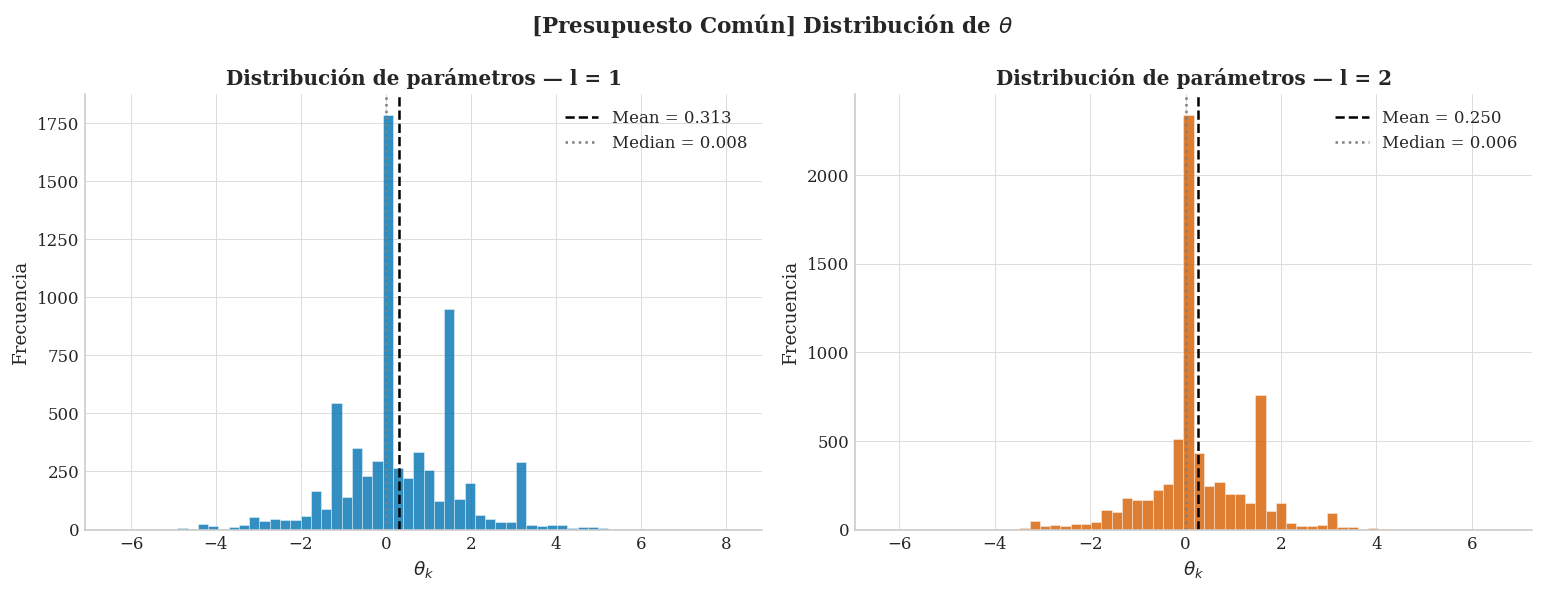

In [111]:
# [Presupuesto común] Distribución de los parámetros theta finales
all_params_l1, all_params_l2 = [], []
for item in data_l1.values():
    all_params_l1.extend(item.get("params", []))
for item in data_l2.values():
    all_params_l2.extend(item.get("params", []))

all_params_l1 = np.array(all_params_l1)
all_params_l2 = np.array(all_params_l2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, params, label, color in [
    (axes[0], all_params_l1, "l = 1", C1),
    (axes[1], all_params_l2, "l = 2", C2),
]:
    ax.hist(params, bins=60, color=color, alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(np.mean(params),   color="black", linestyle="--", linewidth=1.5,
               label=f"Mean = {np.mean(params):.3f}")
    ax.axvline(np.median(params), color="gray",  linestyle=":",  linewidth=1.5,
               label=f"Median = {np.median(params):.3f}")
    ax.set_xlabel(r"$\theta_k$"); ax.set_ylabel("Frecuencia")
    ax.set_title(f"Distribución de parámetros — {label}"); ax.legend()

plt.suptitle(r"[Presupuesto Común] Distribución de $\theta$", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Análisis:** Con presupuesto común, la distribución de parámetros de ambos pools se asemeja más que en el caso normal, pero `l=2` sigue siendo más concentrada alrededor de cero. Esto confirma que la diferencia observada en el caso normal no es solo consecuencia de usar más iteraciones: los operadores de $O_3$ parametrizan el ansatz de forma estructuralmente distinta, requiriendo ángulos más pequeños incluso con el mismo número de pasos. El pico en $\theta \approx 0$ sigue siendo la característica dominante en ambos casos, y su interpretación es la misma que en el caso normal: **correcciones finas acumuladas**, no operadores redundantes.

### 9. Expresividad vs eficiencia por paso — Presupuesto común

Esta sección cuantifica directamente la distinción entre **expresividad** (acceso a mejores mínimos) y **eficiencia por paso** (reducción de energía por operador seleccionado), que es el argumento central del capítulo de discusión.

La métrica utilizada es la **mejora marginal media por iteración**, definida como:

$$\text{eff} = \frac{1}{r}\sum_{k=1}^{r}|E_k - E_{k-1}| = \frac{E_0 - E_{\text{final}}}{r}$$

donde $E_k$ es la energía tras agregar el $k$-ésimo operador al ansatz y reoptimizar todos los parámetros, y $r$ es el número total de iteraciones. La segunda igualdad se obtiene porque la energía es monótonamente decreciente (suma telescópica), de modo que la métrica equivale simplemente a la **pendiente promedio de la curva de convergencia**: cuántas unidades de energía reduce el algoritmo por cada operador que añade al ansatz.

Bajo el **presupuesto común** ($r = r_{\text{common}}$ igual para ambos pools en cada grafo), el punto $(x, y)$ de cada instancia es:

$$x = \frac{E_0 - E_{\text{final}}^{(\ell=1)}}{r_{\text{common}}}, \qquad y = \frac{E_0 - E_{\text{final}}^{(\ell=2)}}{r_{\text{common}}}$$

Si ambos pools son igualmente eficientes por paso, los puntos deben agruparse sobre la diagonal $y = x$.

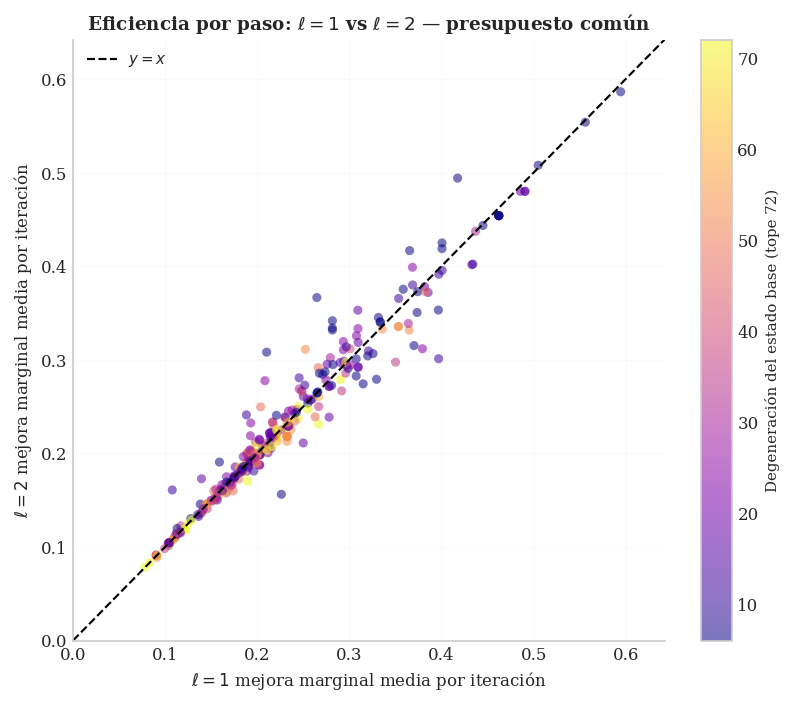

Ratio eff_l2/eff_l1  —  mediana: 0.996  |  media: 1.007
Fraccion grafos con eff_l2 > eff_l1: 43.3%


In [113]:
# Scatter de eficiencia por paso — presupuesto común
from pathlib import Path
import json as _json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def _load(path):
    with open(path, "r", encoding="utf-8") as f:
        raw = _json.load(f)
    return {int(item["grafo_id"]): item for item in raw if "error" not in item}

def mean_marginal(trace):
    diffs = np.abs(np.diff(trace))
    return float(np.mean(diffs)) if len(diffs) > 0 else 0.0

d1 = _load("../resultados/json/resultados_completos_n6_l1_common_budget.json")
d2 = _load("../resultados/json/resultados_completos_n6_l2_common_budget.json")
cids = sorted(set(d1) & set(d2))

eff1 = np.array([mean_marginal(d1[g]["energy_trace"]) for g in cids])
eff2 = np.array([mean_marginal(d2[g]["energy_trace"]) for g in cids])
deg  = np.array([d1[g]["ground_degeneracy"] for g in cids])

norm = mcolors.Normalize(vmin=6, vmax=72)
cmap = plt.cm.plasma

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(eff1, eff2, c=np.clip(deg, 6, 72), cmap=cmap, norm=norm,
                alpha=0.55, s=30, edgecolors="none")
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Degeneración del estado base (tope 72)", fontsize=9)

lim = max(eff1.max(), eff2.max()) * 1.08
ax.plot([0, lim], [0, lim], "k--", lw=1.3, label="$y = x$")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("$\\ell=1$ mejora marginal media por iteración", fontsize=10)
ax.set_ylabel("$\\ell=2$ mejora marginal media por iteración", fontsize=10)
ax.set_title("Eficiencia por paso: $\\ell=1$ vs $\\ell=2$ — presupuesto común", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

ratio = eff2 / np.where(eff1 > 1e-10, eff1, np.nan)
print(f"Ratio eff_l2/eff_l1  —  mediana: {np.nanmedian(ratio):.3f}  |  media: {np.nanmean(ratio):.3f}")
print(f"Fraccion grafos con eff_l2 > eff_l1: {(eff2 > eff1).mean()*100:.1f}%")

**Análisis.**

Bajo el presupuesto común, los puntos se agrupan en torno a la diagonal $y=x$: la mejora marginal media por iteración es estadísticamente equivalente para $\ell=1$ y $\ell=2$, grafo por grafo. El ratio mediano $\text{eff}_{\ell=2}/\text{eff}_{\ell=1}$ (impreso arriba) confirma cuantitativamente esta equivalencia.

El color codifica la degeneración del estado fundamental: los grafos fáciles (alta degeneración, amarillos) presentan eficiencias altas en ambos ejes; los difíciles (baja degeneración, violetas) se acumulan cerca del origen. En todos los rangos de dificultad, el cociente entre eficiencias se mantiene cercano a 1, lo que confirma que la equivalencia por paso no depende de la estructura del grafo.